<a href="https://colab.research.google.com/github/ghadirchhade/Master-Thesis/blob/main/E01_w_tiling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from google.colab import userdata

os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

In [ ]:
!pip install -q torch torchvision

In [ ]:
import torch
import torchvision

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128
CUDA is available: True


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# facebook/sam3 is gated on the Hub -> you must accept the license at
# https://huggingface.co/facebook/sam3 with the account whose token you use below.
!pip install -q -U transformers accelerate huggingface_hub supervision

from huggingface_hub import login
login()  # paste your HF token (needs access to facebook/sam3)

print("Transformers SAM3 dependencies installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 84.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 771.9/771.9 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.2/280.2 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 9.0 MB/s eta 0:00:00
Transformers SAM3 dependencies installed.


In [ ]:
import os
import numpy as np
import torch
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import supervision as sv

from transformers import Sam3Model, Sam3Processor

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

sam3_model = Sam3Model.from_pretrained("facebook/sam3", device_map="auto")
sam3_model.eval()

sam3_processor = Sam3Processor.from_pretrained("facebook/sam3")

print("HF transformers SAM3 model + processor loaded.")
print("Model device:", next(sam3_model.parameters()).device)

Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

HF transformers SAM3 model + processor loaded.
Model device: cuda:0


In [ ]:
IMAGE_PATH = "/content/drive/MyDrive/datasets/AGS_Multi_Rumex/images/20230426_Wallenwil/DJI_20230426110736_0035.JPG"
LABEL_PATH = "/content/drive/MyDrive/datasets/AGS_Multi_Rumex/annotations_yolo/DJI_20230426110736_0035.txt"
RUMEX_CLASS_ID = 0

image = Image.open(IMAGE_PATH).convert("RGB")
img_w, img_h = image.size
print(f"Image size: {image.size}")

Image size: (8192, 5460)


In [ ]:
# ---- Tiling configuration ----
TILE_SIZE = 1024       # max tile edge (kept native-resolution instead of downscaling the whole image)
TILE_OVERLAP = 200     # overlap between neighboring tiles so objects near tile borders aren't missed
REF_MARGIN = 20        # gap (px) between the pasted exemplar reference panel and the tile image
EXEMPLAR_PAD_FRAC = 0.25  # extra context padding around the exemplar box when cropping the reference patch

def make_tile_boxes(img_w, img_h, tile_size=TILE_SIZE, overlap=TILE_OVERLAP):
    """Return list of (x0, y0, x1, y1) tile boxes covering the full image with overlap."""
    stride = max(tile_size - overlap, 1)

    def axis_starts(total, size, stride):
        if total <= size:
            return [0]
        starts = list(range(0, total - size + 1, stride))
        if starts[-1] != total - size:
            starts.append(total - size)
        return starts

    xs = axis_starts(img_w, tile_size, stride)
    ys = axis_starts(img_h, tile_size, stride)

    tiles = []
    for y0 in ys:
        for x0 in xs:
            x1 = min(x0 + tile_size, img_w)
            y1 = min(y0 + tile_size, img_h)
            tiles.append((x0, y0, x1, y1))
    return tiles

tile_boxes = make_tile_boxes(img_w, img_h)
print(f"Image split into {len(tile_boxes)} tiles of up to {TILE_SIZE}x{TILE_SIZE} px (overlap={TILE_OVERLAP}px).")

Image split into 70 tiles of up to 1024x1024 px (overlap=200px).


In [ ]:
import matplotlib.font_manager as fm

font_path = fm.findfont("DejaVu Sans")
print(font_path)

/usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf


In [ ]:
# GT box loading (unchanged, full-res only — no scale factor needed anymore)
def load_yolo_boxes(label_path, img_width, img_height, class_id=0):
    boxes = []
    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            cls = int(parts[0])
            if cls != class_id:
                continue
            xc, yc, bw, bh = map(float, parts[1:5])
            xc, yc, bw, bh = xc * img_width, yc * img_height, bw * img_width, bh * img_height
            boxes.append([xc - bw / 2, yc - bh / 2, xc + bw / 2, yc + bh / 2])
    return np.array(boxes, dtype=np.float32)

gt_boxes = load_yolo_boxes(LABEL_PATH, img_w, img_h, class_id=RUMEX_CLASS_ID)
print(f"Loaded {len(gt_boxes)} GT box(es) with class id={RUMEX_CLASS_ID}.")

# (Same yellow/index GT visualization as before, at full resolution — omitted here for brevity,
# reuse your existing "visualize all GT bboxes" cell unchanged, it doesn't depend on sam_scale.)

Loaded 57 GT box(es) with class id=0.


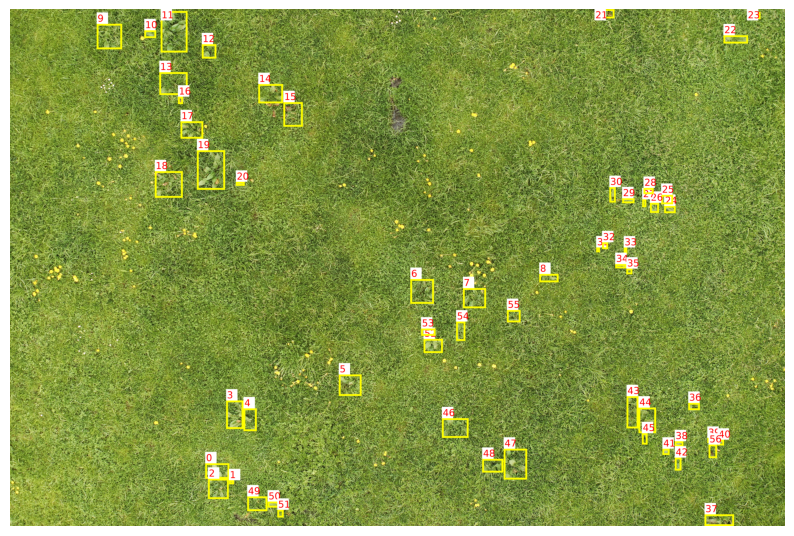

In [ ]:
#visualize all GT bboxes

gt_preview = image.copy()
draw = ImageDraw.Draw(gt_preview)

# Find available font
font_path = fm.findfont("DejaVu Sans")
font = ImageFont.truetype(font_path, 100)

for i, (x0, y0, x1, y1) in enumerate(gt_boxes):

    # Draw bounding box
    draw.rectangle([x0, y0, x1, y1],outline=(255, 255, 0),width=20)

    # Text position
    text_x = int(x0)
    text_y = max(0, int(y0)-120)

    # Background rectangle for label
    draw.rectangle([text_x, text_y, text_x+120, text_y+120],fill=(255, 255, 255))

    # Draw index
    draw.text((text_x+10, text_y+5),str(i),fill=(255, 0, 0),font=font)

plt.figure(figsize=(10,8))
plt.imshow(gt_preview)
plt.axis("off")
plt.show()

Selected exemplar index: 6
Exemplar reference patch size: (375, 394)


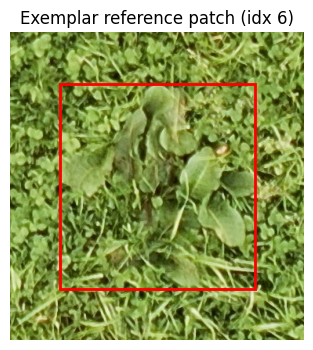

In [ ]:
# ---- Build the exemplar reference patch (full resolution, no scaling) ----
exemplar_index = 6
ex_x0, ex_y0, ex_x1, ex_y1 = gt_boxes[exemplar_index]
box_w, box_h = ex_x1 - ex_x0, ex_y1 - ex_y0
pad_x, pad_y = box_w * EXEMPLAR_PAD_FRAC, box_h * EXEMPLAR_PAD_FRAC

crop_x0 = max(0, int(ex_x0 - pad_x))
crop_y0 = max(0, int(ex_y0 - pad_y))
crop_x1 = min(img_w, int(ex_x1 + pad_x))
crop_y1 = min(img_h, int(ex_y1 + pad_y))

exemplar_patch = image.crop((crop_x0, crop_y0, crop_x1, crop_y1))

# box of the actual exemplar plant *within* the cropped reference patch
ref_box_local = [float(ex_x0 - crop_x0), float(ex_y0 - crop_y0),
                  float(ex_x1 - crop_x0), float(ex_y1 - crop_y0)]

print(f"Selected exemplar index: {exemplar_index}")
print(f"Exemplar reference patch size: {exemplar_patch.size}")

plt.figure(figsize=(4, 4))
plt.imshow(exemplar_patch)
ax = plt.gca()
ax.add_patch(plt.Rectangle(
    (ref_box_local[0], ref_box_local[1]),
    ref_box_local[2] - ref_box_local[0],
    ref_box_local[3] - ref_box_local[1],
    fill=False, edgecolor="red", linewidth=2,
))
plt.title(f"Exemplar reference patch (idx {exemplar_index})")
plt.axis("off")
plt.show()

In [ ]:
# Show ALL GT boxes (yellow) with their indices, and separately highlight
# the chosen exemplar box (e.g. thicker green outline + "EXEMPLAR" label)
# so the original yellow GT box for it is still visible underneath.
# (unchanged — still works with full-res gt_boxes / image / exemplar_index)

exemplar_preview = image.copy()
draw = ImageDraw.Draw(exemplar_preview)

for i, (bx0, by0, bx1, by1) in enumerate(gt_boxes):
    draw.rectangle([bx0, by0, bx1, by1], outline=(255, 255, 0), width=20)
    text_x, text_y = int(bx0), max(0, int(by0) - 120)
    draw.rectangle([text_x, text_y, text_x + 120, text_y + 120], fill=(255, 255, 255))
    draw.text((text_x + 10, text_y + 5), str(i), fill=(255, 0, 0), font=font)

# Highlight the chosen exemplar box on top, without covering the yellow GT box
ex_x0, ex_y0, ex_x1, ex_y1 = gt_boxes[exemplar_index]
HIGHLIGHT_PAD = 15  # draw slightly outside the GT box so both outlines stay visible

draw.rectangle(
    [ex_x0 - HIGHLIGHT_PAD, ex_y0 - HIGHLIGHT_PAD, ex_x1 + HIGHLIGHT_PAD, ex_y1 + HIGHLIGHT_PAD],
    outline=(0, 255, 0),
    width=20,
)

# "EXEMPLAR" label near the highlighted box
label_text = f"EXEMPLAR (idx {exemplar_index})"
label_x, label_y = int(ex_x0 - HIGHLIGHT_PAD), int(ex_y1 + HIGHLIGHT_PAD + 20)
label_font = ImageFont.truetype(font_path, 90)
text_bbox = draw.textbbox((label_x, label_y), label_text, font=label_font)
draw.rectangle(text_bbox, fill=(0, 255, 0))
draw.text((label_x, label_y), label_text, fill=(0, 0, 0), font=label_font)

plt.figure(figsize=(12, 10))
plt.imshow(exemplar_preview)
plt.axis("off")
plt.title("All GT boxes (yellow) — green outline marks the chosen exemplar")
plt.show()

In [ ]:
# ---- Helpers: tensor->numpy (same as before) ----
def to_numpy(x):
    if torch.is_tensor(x):
        if x.dtype in (torch.bfloat16, torch.float16):
            x = x.float()
        return x.detach().cpu().numpy()
    if isinstance(x, (list, tuple)):
        if len(x) > 0 and torch.is_tensor(x[0]):
            x = [t.float() if t.dtype in (torch.bfloat16, torch.float16) else t for t in x]
            return torch.stack([t.detach().cpu() for t in x]).numpy()
        return np.array(x)
    return np.array(x)

In [ ]:
def build_composite(tile_img, exemplar_patch, ref_box_local, margin=REF_MARGIN):
    """
    Paste the exemplar reference patch to the LEFT of the tile image (separated by a
    margin) so SAM3 receives a single image containing both:
      - the reference patch with its known exemplar box (defines "the concept")
      - the tile to search for other instances of that concept
    Returns: composite PIL image, the exemplar box (xyxy) within the composite, and
    x_offset (= resized reference width + margin) used to map composite coords -> tile coords.
    """
    tile_w, tile_h = tile_img.size
    ref_w, ref_h = exemplar_patch.size

    scale = tile_h / ref_h
    ref_resized = exemplar_patch.resize((max(1, int(ref_w * scale)), tile_h), Image.BILINEAR)
    ref_box_resized = [float(c * scale) for c in ref_box_local]

    x_offset = ref_resized.width + margin
    composite = Image.new("RGB", (x_offset + tile_w, tile_h), (0, 0, 0))
    composite.paste(ref_resized, (0, 0))
    composite.paste(tile_img, (x_offset, 0))

    return composite, ref_box_resized, x_offset

In [ ]:
# ---- Preview one composed tile (reference panel + tile, with the exemplar box drawn) ----

# Pick the tile that actually contains the exemplar plant, so the preview is meaningful
ex_cx, ex_cy = (ex_x0 + ex_x1) / 2, (ex_y0 + ex_y1) / 2
demo_tile_box = next(
    (tb for tb in tile_boxes if tb[0] <= ex_cx < tb[2] and tb[1] <= ex_cy < tb[3]),
    tile_boxes[0],  # fallback if nothing matches
)
demo_tx0, demo_ty0, demo_tx1, demo_ty1 = demo_tile_box

demo_tile_img = image.crop((demo_tx0, demo_ty0, demo_tx1, demo_ty1))
demo_composite, demo_ref_box, demo_x_offset = build_composite(demo_tile_img, exemplar_patch, ref_box_local)

preview = demo_composite.copy()
draw = ImageDraw.Draw(preview)

# Reference exemplar box (drawn on the pasted reference panel, left side)
draw.rectangle(demo_ref_box, outline=(0, 255, 0), width=8)
draw.text((demo_ref_box[0], max(0, demo_ref_box[1] - 30)), "EXEMPLAR", fill=(0, 255, 0), font=font)

# Line marking the boundary between the reference panel and the actual tile
draw.line([(demo_x_offset, 0), (demo_x_offset, preview.height)], fill=(255, 0, 0), width=6)

plt.figure(figsize=(14, 6))
plt.imshow(preview)
plt.axis("off")
plt.title(f"Composite fed to SAM3 — tile ({demo_tx0},{demo_ty0})-({demo_tx1},{demo_ty1})")
plt.show()

print(f"Composite size: {demo_composite.size}  |  reference panel width (x_offset): {demo_x_offset}")

In [ ]:
def run_sam3_on_tile(tile_box):
    tx0, ty0, tx1, ty1 = tile_box
    tile_img = image.crop((tx0, ty0, tx1, ty1))
    tile_w, tile_h = tile_img.size

    composite, ref_box_composite, x_offset = build_composite(tile_img, exemplar_patch, ref_box_local)

    inputs = sam3_processor(
        images=composite,
        input_boxes=[[ref_box_composite]],
        input_boxes_labels=[[1]],
        return_tensors="pt",
    ).to(sam3_model.device)

    with torch.no_grad():
        outputs = sam3_model(**inputs)

    results = sam3_processor.post_process_instance_segmentation(
        outputs,
        threshold=0.3,
        mask_threshold=0.5,
        target_sizes=inputs.get("original_sizes").tolist(),
    )[0]

    boxes = to_numpy(results["boxes"])
    scores = to_numpy(results["scores"])
    masks = to_numpy(results["masks"])

    empty = (np.zeros((0, 4), dtype=np.float32), np.zeros((0,), dtype=np.float32),
              np.zeros((0, tile_h, tile_w), dtype=bool))
    if len(boxes) == 0:
        return empty

    # Drop detections that are (mostly) inside the pasted reference panel -- these are
    # just the model re-finding the reference exemplar itself, not real tile detections.
    keep = boxes[:, 0] >= (x_offset - 5)
    boxes, scores, masks = boxes[keep], scores[keep], masks[keep]
    if len(boxes) == 0:
        return empty

    # Composite-local -> tile-local
    boxes = boxes.copy()
    boxes[:, [0, 2]] -= x_offset
    tile_masks = masks[:, :, x_offset:]

    # Tile-local -> full image coords
    boxes[:, [0, 2]] += tx0
    boxes[:, [1, 3]] += ty0

    return boxes, scores, tile_masks

In [ ]:
# ---- Run SAM3 tile-by-tile and collect detections into full-image coordinates ----
all_boxes, all_scores, all_masks_full = [], [], []

for i, tb in enumerate(tile_boxes):
    tx0, ty0, tx1, ty1 = tb
    boxes, scores, tile_masks = run_sam3_on_tile(tb)

    for b, s, m in zip(boxes, scores, tile_masks):
        full_mask = np.zeros((img_h, img_w), dtype=bool)
        full_mask[ty0:ty1, tx0:tx1] = m
        all_boxes.append(b)
        all_scores.append(s)
        all_masks_full.append(full_mask)

    print(f"Tile {i+1}/{len(tile_boxes)}  ({tx0},{ty0})-({tx1},{ty1}): {len(boxes)} detection(s)")

all_boxes = np.array(all_boxes, dtype=np.float32) if all_boxes else np.zeros((0, 4), dtype=np.float32)
all_scores = np.array(all_scores, dtype=np.float32) if all_scores else np.zeros((0,), dtype=np.float32)
all_masks_full = np.array(all_masks_full, dtype=bool) if all_masks_full else np.zeros((0, img_h, img_w), dtype=bool)

print(f"\nTotal raw detections across all tiles (pre-NMS): {len(all_boxes)}")

# ---- Merge duplicate detections from overlapping tiles (box-based NMS, no mask IoU) ----
def compute_iou_matrix(boxes1, boxes2):
    if len(boxes1) == 0 or len(boxes2) == 0:
        return np.zeros((len(boxes1), len(boxes2)))
    x1 = np.maximum(boxes1[:, None, 0], boxes2[None, :, 0])
    y1 = np.maximum(boxes1[:, None, 1], boxes2[None, :, 1])
    x2 = np.minimum(boxes1[:, None, 2], boxes2[None, :, 2])
    y2 = np.minimum(boxes1[:, None, 3], boxes2[None, :, 3])
    inter_w = np.clip(x2 - x1, 0, None)
    inter_h = np.clip(y2 - y1, 0, None)
    inter_area = inter_w * inter_h
    area1 = (boxes1[:, 2] - boxes1[:, 0]) * (boxes1[:, 3] - boxes1[:, 1])
    area2 = (boxes2[:, 2] - boxes2[:, 0]) * (boxes2[:, 3] - boxes2[:, 1])
    union_area = area1[:, None] + area2[None, :] - inter_area
    return np.where(union_area > 0, inter_area / union_area, 0.0)


def nms_indices(boxes, scores, iou_threshold=0.5):
    order = np.argsort(-scores)
    suppressed = np.zeros(len(boxes), dtype=bool)
    keep = []
    for idx in order:
        if suppressed[idx]:
            continue
        keep.append(idx)
        ious = compute_iou_matrix(boxes[idx:idx + 1], boxes)[0]
        suppressed |= (ious > iou_threshold)
        suppressed[idx] = False  # already kept, don't let self-suppress skip bookkeeping
    return keep


keep_idx = nms_indices(all_boxes, all_scores, iou_threshold=0.5)

pred_boxes_np = all_boxes[keep_idx]
pred_scores_np = all_scores[keep_idx]
full_res_masks = all_masks_full[keep_idx]

pred_detections = sv.Detections(
    xyxy=pred_boxes_np,
    confidence=pred_scores_np,
    class_id=np.zeros(len(pred_scores_np), dtype=int),
    mask=full_res_masks,
)

print(f"Detections after cross-tile NMS: {len(pred_boxes_np)}")

Tile 1/70  (0,0)-(1024,1024): 2 detection(s)
Tile 2/70  (824,0)-(1848,1024): 4 detection(s)
Tile 3/70  (1648,0)-(2672,1024): 4 detection(s)
Tile 4/70  (2472,0)-(3496,1024): 1 detection(s)
Tile 5/70  (3296,0)-(4320,1024): 0 detection(s)
Tile 6/70  (4120,0)-(5144,1024): 0 detection(s)
Tile 7/70  (4944,0)-(5968,1024): 0 detection(s)
Tile 8/70  (5768,0)-(6792,1024): 1 detection(s)
Tile 9/70  (6592,0)-(7616,1024): 0 detection(s)
Tile 10/70  (7168,0)-(8192,1024): 0 detection(s)
Tile 11/70  (0,824)-(1024,1848): 0 detection(s)
Tile 12/70  (824,824)-(1848,1848): 2 detection(s)
Tile 13/70  (1648,824)-(2672,1848): 2 detection(s)
Tile 14/70  (2472,824)-(3496,1848): 0 detection(s)
Tile 15/70  (3296,824)-(4320,1848): 0 detection(s)
Tile 16/70  (4120,824)-(5144,1848): 0 detection(s)
Tile 17/70  (4944,824)-(5968,1848): 0 detection(s)
Tile 18/70  (5768,824)-(6792,1848): 0 detection(s)
Tile 19/70  (6592,824)-(7616,1848): 0 detection(s)
Tile 20/70  (7168,824)-(8192,1848): 0 detection(s)
Tile 21/70  (0,16

In [ ]:
# Load ground-truth boxes from the YOLO-format label file
def load_yolo_boxes(label_path, img_width, img_height, class_id=0):
    boxes = []
    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            cls = int(parts[0])
            if cls != class_id:
                continue
            xc, yc, bw, bh = map(float, parts[1:5])
            xc, yc, bw, bh = xc * img_width, yc * img_height, bw * img_width, bh * img_height
            boxes.append([xc - bw / 2, yc - bh / 2, xc + bw / 2, yc + bh / 2])
    return np.array(boxes, dtype=np.float32)

gt_boxes = load_yolo_boxes(LABEL_PATH, img_w, img_h, class_id=RUMEX_CLASS_ID)
print(f"Loaded {len(gt_boxes)} GT box(es).")

Loaded 57 GT box(es).


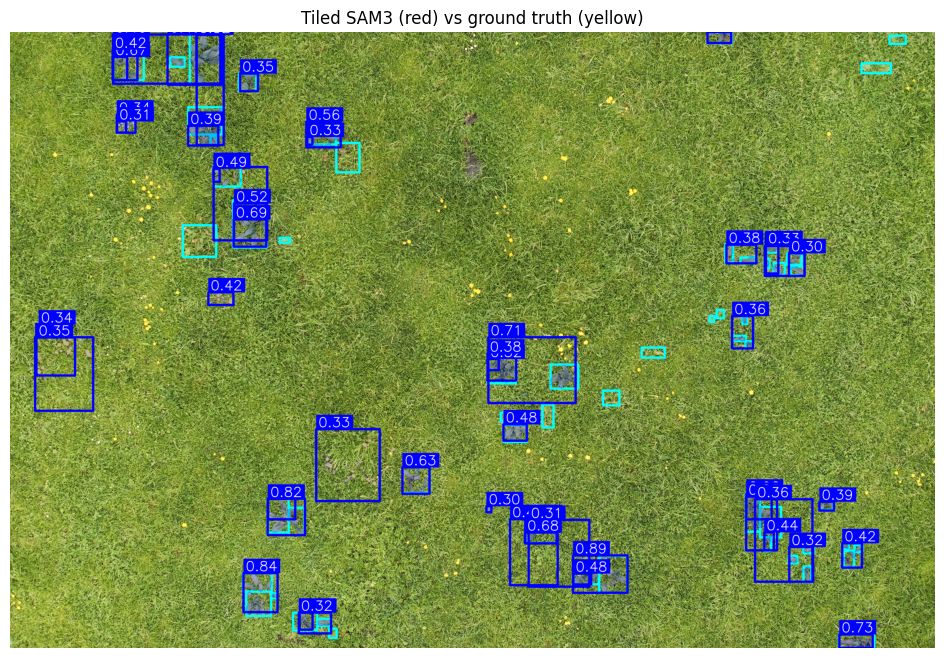

In [ ]:
#Visualization
image_np = np.array(image)

gt_detections = sv.Detections(
    xyxy=gt_boxes,
    class_id=np.zeros(len(gt_boxes), dtype=int),
)

red_annotator = sv.BoxAnnotator(color=sv.Color.RED, color_lookup=sv.ColorLookup.INDEX, thickness=20)
yellow_annotator = sv.BoxAnnotator(color=sv.Color.YELLOW, color_lookup=sv.ColorLookup.INDEX, thickness=20)
mask_annotator = sv.MaskAnnotator(color=sv.Color.RED, color_lookup=sv.ColorLookup.INDEX, opacity=0.25)
label_annotator = sv.LabelAnnotator(
    color=sv.Color.RED, text_color=sv.Color.WHITE,
    text_scale=4.0, text_thickness=6, text_padding=20,
)

annotated = yellow_annotator.annotate(scene=image_np.copy(), detections=gt_detections)
annotated = mask_annotator.annotate(scene=annotated, detections=pred_detections)
annotated = red_annotator.annotate(scene=annotated, detections=pred_detections)
annotated = label_annotator.annotate(
    scene=annotated, detections=pred_detections,
    labels=[f"{s:.2f}" for s in pred_scores_np],
)

plt.figure(figsize=(12, 8))
plt.imshow(annotated)
plt.axis("off")
plt.title("Tiled SAM3 (red) vs ground truth (yellow)")
plt.show()

In [ ]:
#Metrics
from supervision.metrics import MeanAveragePrecision

map_metric = MeanAveragePrecision()
result = map_metric.update([pred_detections], [gt_detections]).compute()
print(f"mAP50: {result.map50:.4f}")

def compute_iou_matrix(boxes1, boxes2):
    if len(boxes1) == 0 or len(boxes2) == 0:
        return np.zeros((len(boxes1), len(boxes2)))
    x1 = np.maximum(boxes1[:, None, 0], boxes2[None, :, 0])
    y1 = np.maximum(boxes1[:, None, 1], boxes2[None, :, 1])
    x2 = np.minimum(boxes1[:, None, 2], boxes2[None, :, 2])
    y2 = np.minimum(boxes1[:, None, 3], boxes2[None, :, 3])
    inter_w = np.clip(x2 - x1, 0, None)
    inter_h = np.clip(y2 - y1, 0, None)
    inter_area = inter_w * inter_h
    area1 = (boxes1[:, 2] - boxes1[:, 0]) * (boxes1[:, 3] - boxes1[:, 1])
    area2 = (boxes2[:, 2] - boxes2[:, 0]) * (boxes2[:, 3] - boxes2[:, 1])
    union_area = area1[:, None] + area2[None, :] - inter_area
    return np.where(union_area > 0, inter_area / union_area, 0.0)

IOU_THRESHOLD = 0.5
iou_matrix = compute_iou_matrix(pred_boxes_np, gt_boxes)
num_preds, num_gt = len(pred_boxes_np), len(gt_boxes)

matched_gt = set()
true_positives = 0
matched_ious = []
pred_order = np.argsort(-pred_scores_np) if num_preds > 0 else []

for pred_idx in pred_order:
    if num_gt == 0:
        break
    best_gt_idx = np.argmax(iou_matrix[pred_idx])
    best_iou = iou_matrix[pred_idx, best_gt_idx]
    if best_iou >= IOU_THRESHOLD and best_gt_idx not in matched_gt:
        matched_gt.add(best_gt_idx)
        true_positives += 1
        matched_ious.append(best_iou)

false_positives = num_preds - true_positives
false_negatives = num_gt - true_positives
precision = true_positives / num_preds if num_preds > 0 else 0.0
recall = true_positives / num_gt if num_gt > 0 else 0.0
mean_iou_matched = float(np.mean(matched_ious)) if matched_ious else 0.0
mean_iou_all_gt = float(np.sum(matched_ious) / num_gt) if num_gt > 0 else 0.0

print(f"IoU threshold: {IOU_THRESHOLD}")
print(f"Num predictions: {num_preds} | Num GT boxes: {num_gt}")
print(f"True Positives:  {true_positives}")
print(f"False Positives: {false_positives}")
print(f"False Negatives: {false_negatives}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"Mean IoU (matched pairs only): {mean_iou_matched:.4f}")
print(f"Mean IoU (over all GT boxes):  {mean_iou_all_gt:.4f}")

mAP50: 0.1237
IoU threshold: 0.5
Num predictions: 52 | Num GT boxes: 57
True Positives:  15
False Positives: 37
False Negatives: 42
Precision: 0.2885
Recall:    0.2632
Mean IoU (matched pairs only): 0.7722
Mean IoU (over all GT boxes):  0.2032
